In [1]:
import sys # Imports Python's system module- It allows you to interact with the Python interpreter, such as modifying where Python looks for files to import.
sys.path.append("..") # Add parent folder so imports like utils.py work
import warnings # This imports Python's warnings module.
warnings.filterwarnings("ignore") # Ignore all warning messages.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import load_raw_data
import seaborn as sns



==========================================================
#### STEP 1: EXPLORATORY DATA ANALYSIS (EDA)
#### YouTube Comments Sentiment Dataset
==========================================================

 ------------------------------------------------------------------
 1. Load data
 ------------------------------------------------------------------

In [2]:
df = load_raw_data("../data/comments.csv")
print("Shape:", df.shape)
df.head()

Shape: (103482, 12)


,CommentID,VideoID,VideoTitle,AuthorName,AuthorChannelID,CommentText,Sentiment,Likes,Replies,PublishedAt,CountryCode,CategoryID
0,UgyRjrEdJIPrf68uND14AaABAg,mcY4M9gjtsI,They killed my friend.#tales #movie #shorts,@OneWhoWandered,UC_-UEXaBL1dqqUPGkDll49A,Anyone know what movie this is?,Neutral,0,2,15-01-2025 00:54,NZ,1
1,UgxXxEIySAwnMNw8D7N4AaABAg,2vuXcw9SZbA,Man Utd conceding first penalty at home in yea...,@chiefvon3068,UCZ1LcZESjYqzaQRhjdZJFwg,The fact they're holding each other back while...,Positive,0,0,13-01-2025 23:51,AU,17
2,UgxB0jh2Ur41mcXr5IB4AaABAg,papg2tsoFzg,Welcome to Javascript Course,@Abdulla-ip8qr,UCWBK35w5Swy1iF5xIbEyw3A,waiting next video will be?,Neutral,1,0,06-07-2020 13:18,IN,27
3,UgwMOh95MfK0GuXLLrF4AaABAg,31KTdfRH6nY,Building web applications in Java with Spring ...,@finnianthehuman,UCwQ2Z03nOcMxWozBb_Cv66w,Thanks for the great video. I don't understand...,Neutral,0,1,18-09-2024 12:04,US,27
4,UgxJuUe5ysG8OSbABAl4AaABAg,#NAME?,After a new engine her car dies on her way hom...,@ryoutubeplaylistb6137,UCTTcJ0tsAKQokmHB2qVb1qQ,Good person helping good people. This is how i...,Positive,3,1,10-01-2025 19:39,US,2


 ------------------------------------------------------------------
 2. Basic info / missing values / duplicates
 ------------------------------------------------------------------

In [3]:
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate comment texts:", df["CommentText"].duplicated().sum())

CommentID          object
VideoID            object
VideoTitle         object
AuthorName         object
AuthorChannelID    object
CommentText        object
Sentiment          object
Likes               int64
Replies             int64
PublishedAt        object
CountryCode        object
CategoryID          int64
dtype: object

Missing values:
 CommentID           0
VideoID             0
VideoTitle          0
AuthorName         71
AuthorChannelID     0
CommentText         0
Sentiment           0
Likes               0
Replies             0
PublishedAt         0
CountryCode         0
CategoryID          0
dtype: int64

Duplicate rows: 0
Duplicate comment texts: 2152


 ------------------------------------------------------------------
 3. Target variable distribution (Sentiment)
 ------------------------------------------------------------------

In [4]:
print(df["Sentiment"].value_counts())
print(df["Sentiment"].value_counts(normalize=True))

Sentiment
Negative    35073
Positive    34308
Neutral     34101
Name: count, dtype: int64
Sentiment
Negative    0.338929
Positive    0.331536
Neutral     0.329536
Name: proportion, dtype: float64


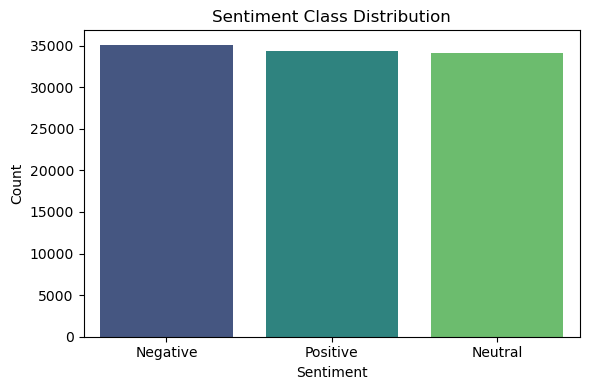

In [5]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Sentiment",
    order=df["Sentiment"].value_counts().index,
    palette="viridis"
)

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.tight_layout()
plt.show()